#**KNOWLEDGE GRAPH EXPLOITATION**

This is the notebook associated with the assignment **Knowledge Graph Exploitation**. In LearnSQL you can find the assignment statament, so please carefully read it while following the scripts, answering all the questions and compleating the tasks. Remember to change the **Runtime** settings to include GPU access.

Before starting, we will install and import the required libraries:

In [ ]:
!pip install torch
!pip install torch-geometric
!pip install pykeen

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\pablo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\pablo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\pablo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Found existing installation: torchvision 0.27.0
Uninstalling torchvision-0.27.0:
  Successfully uninstalled torchvision-0.27.0
Found existing installation: torchaudio 2.11.0
Uninstalling torchaudio-2.11.0:
  Successfully uninstalled torchaudio-2.11.0


In [1]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## **Creating the Knowledge Graph**

In [2]:
import numpy as np
from pykeen.triples import TriplesFactory
from torch_geometric.datasets import Planetoid


dataset = Planetoid(root='data/PubMed', name='PubMed')
data = dataset[0]

edge_index = data.edge_index

# Convert to numpy
heads = edge_index[0].cpu().numpy()
tails = edge_index[1].cpu().numpy()

# Create string triples
triples = np.array([
    [f"paper_{h}", "cites", f"paper_{t}"]
    for h, t in zip(heads, tails)
])

tf = TriplesFactory.from_labeled_triples(triples)

training, testing, validation = tf.split([0.8, 0.1, 0.1],random_state=2026)

C:\Users\pablo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## **A.1 The Most Basic Model**

First of all, we will start generating embeddings with TransE, a very simple and interpretable
model. Do not worry about obtaining the optimal results, a model with a sensible hyperpa-
rameter configuration will be enough, but get familiar with some of the capabilities provided
by PyKEEN https://pykeen.readthedocs.io/en/stable/tutorial/first_steps.html.
Once you have the embeddings, choose a paper from the KG and compute the most probable
embedding for a paper that cites works similar to the ones the paper you have chosen may
cite. Provide a 2D sketch of your reasoning. Then retrieve the actual paper whose embedding
lies closest to the vector you found.




C:\Users\pablo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Training epochs on cpu: 100%|██████████| 100/100 [04:54<00:00,  2.95s/epoch, loss=0.125, prev_loss=0.122]
Evaluating on cpu:   0%|          | 0.00/8.87k [00:00<?, ?triple/s]WARNING:torch_max_mem.api:Encountered tensors on device_types={'cpu'} while only ['cuda'] are considered safe for automatic memory utilization maximization. This may lead to undocumented crashes (but can be safe, too).
Evaluating on cpu: 100%|██████████| 8.87k/8.87k [01:09<00:00, 127triple/s]
INFO:pykeen.evaluation.evaluator:Evaluation took 70.09s seconds


     Side    Rank_type              Metric      Value
0    head   optimistic  harmonic_mean_rank  23.045177
1    tail   optimistic  harmonic_mean_rank  24.199373
2    both   optimistic  harmonic_mean_rank  23.608176
3    head    realistic  harmonic_mean_rank  23.045179
4    tail    realistic  harmonic_mean_rank  24.199375
..    ...          ...                 ...        ...
220  tail    realistic  adjusted_hits_at_k   0.112353
221  both    realistic  adjusted_hits_at_k   0.114948
222  head  pessimistic  adjusted_hits_at_k   0.117544
223  tail  pessimistic  adjusted_hits_at_k   0.112353
224  both  pessimistic  adjusted_hits_at_k   0.114948

[225 rows x 4 columns]


<Axes: title={'center': 'Losses Plot'}, xlabel='Epoch', ylabel='marginranking Loss'>

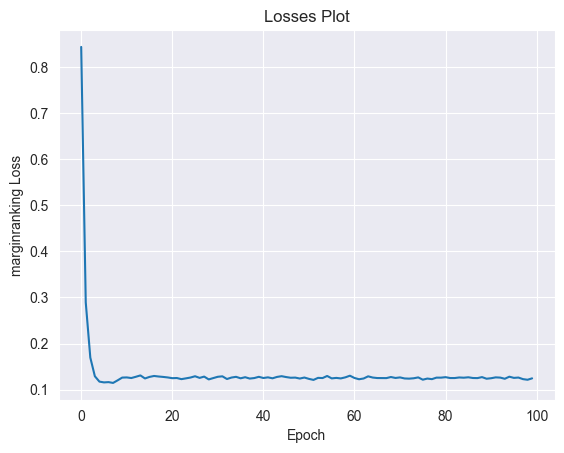

In [3]:
from pykeen.pipeline import pipeline

result_transe = pipeline(
    training=training,
    testing=testing,
    validation=validation,
    model='TransE',
    model_kwargs=dict(embedding_dim=50),
    optimizer='Adam',
    optimizer_kwargs=dict(lr=0.01),
    training_loop='sLCWA',
    negative_sampler='basic',
    epochs=100,
    random_seed=2026,
    device=device,
)

print(result_transe.metric_results.to_df())
result_transe.plot_losses()

In [4]:
import numpy as np

# Extract entity and relation embeddings from the trained TransE model
entity_embs = result_transe.model.entity_representations[0]().detach().cpu().numpy()
relation_embs = result_transe.model.relation_representations[0]().detach().cpu().numpy()

entity_to_id = result_transe.training.entity_to_id
relation_to_id = result_transe.training.relation_to_id
id_to_entity = {v: k for k, v in entity_to_id.items()}

# Choose a paper
chosen_paper = "paper_0"
paper_id = entity_to_id[chosen_paper]
cites_id = relation_to_id["cites"]

# TransE reasoning: head + relation -> predicted tail
# "A paper that cites works similar to those paper_0 may cite"
# => paper_0 + r_cites  gives the embedding of the expected cited paper
# => a paper X that cites similar works satisfies X ≈ paper_0 + r_cites - r_cites = paper_0
# => equivalently, find X whose predicted tail (X + r_cites) is closest to (paper_0 + r_cites)
h_emb = entity_embs[paper_id]
r_emb = relation_embs[cites_id]
predicted_tail = h_emb + r_emb  # embedding TransE predicts for paper_0's cited paper

# Find the actual paper whose embedding is closest to predicted_tail
distances = np.linalg.norm(entity_embs - predicted_tail, axis=1)
distances[paper_id] = np.inf  # exclude chosen paper itself
nearest_id = np.argmin(distances)
nearest_paper = id_to_entity[nearest_id]

print(f"Chosen paper    : {chosen_paper}")
print(f"Predicted cited : {nearest_paper}  (L2 distance = {distances[nearest_id]:.4f})")


Chosen paper    : paper_0
Predicted cited : paper_9861  (L2 distance = 0.8563)


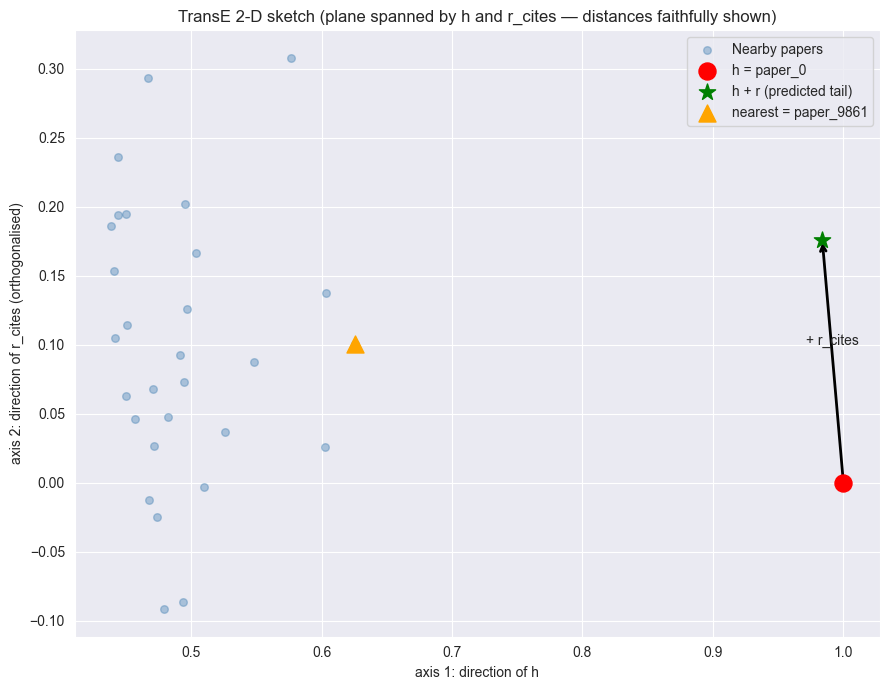

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Project onto the plane spanned by h and r_cites (Gram-Schmidt).
# This keeps the h -> h+r arrow visible and preserves distances between
# h, predicted_tail and nearest_paper, unlike a global PCA.
def project_plane(vecs, u, v):
    e1 = u / (np.linalg.norm(u) + 1e-12)
    v2 = v - np.dot(v, e1) * e1
    e2 = v2 / (np.linalg.norm(v2) + 1e-12)
    return vecs @ np.stack([e1, e2], axis=1)

k = 30
all_distances = np.linalg.norm(entity_embs - predicted_tail, axis=1)
top_k_ids = np.argsort(all_distances)[:k].tolist()
plot_ids = list(set(top_k_ids + [paper_id, nearest_id]))

pts = np.vstack([entity_embs[plot_ids], predicted_tail.reshape(1, -1)])
pts_2d = project_plane(pts, h_emb, r_emb)
h_2d   = project_plane(h_emb.reshape(1, -1), h_emb, r_emb)[0]
pt_2d  = pts_2d[-1]
nn_2d  = project_plane(entity_embs[nearest_id].reshape(1, -1), h_emb, r_emb)[0]

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(pts_2d[:-1, 0], pts_2d[:-1, 1], c="steelblue", alpha=0.4, s=30, label="Nearby papers")
ax.scatter(h_2d[0],  h_2d[1],  c="red",    s=150, zorder=5, label=f"h = {chosen_paper}")
ax.scatter(pt_2d[0], pt_2d[1], c="green",  s=150, marker="*", zorder=5, label="h + r (predicted tail)")
ax.scatter(nn_2d[0], nn_2d[1], c="orange", s=150, marker="^", zorder=5, label=f"nearest = {nearest_paper}")

ax.annotate("", xy=pt_2d, xytext=h_2d,
            arrowprops=dict(arrowstyle="->", color="black", lw=2))
span = pts_2d[:, 1].max() - pts_2d[:, 1].min()
mid = (h_2d + pt_2d) / 2
ax.text(mid[0], mid[1] + span * 0.03, "+ r_cites", fontsize=10, ha="center")

ax.set_title("TransE 2-D sketch
(plane spanned by h and r_cites — distances faithfully shown)")
ax.set_xlabel("axis 1: direction of h")
ax.set_ylabel("axis 2: direction of r_cites (orthogonalised)")
ax.legend()
plt.tight_layout()
plt.show()


## **A.2 Improving TransE**

In [ ]:
# Find the requested paper here

## **A.3 Training KGEs**

In [ ]:
# Train the different KGE models

## **A.4 Negative Sampling**

In [ ]:
# Obtain the corruption probabilities here

## **Loading the full PubMed Dataset**

In [ ]:
from torch_geometric.datasets import Planetoid

dataset = Planetoid(root='data/PubMed', name='PubMed')
data = dataset[0]

print(data)
print("Number of node features:", dataset.num_node_features)
print("Number of classes:", dataset.num_classes)

data = data.to('cuda' if torch.cuda.is_available() else 'cpu')

## **B.1: Let's Forget About the Graph**

In [ ]:
import numpy as np

X = data.x.cpu().numpy()
y = data.y.cpu().numpy()

train_mask = data.train_mask.cpu().numpy()
test_mask = data.test_mask.cpu().numpy()

X_train = X[train_mask]
y_train = y[train_mask]

X_test = X[test_mask]
y_test = y[test_mask]

With the dataset above, train three or four simple classifiers (e.g., SVM, LR, RF, KNN...) and report the accuracy score over the test set for them.

*Note: use **sklearn** for simplicity.*

## **B.2: Exploiting the Graph Structure**

Now, we are going to create a GNN with graph layers and a final linear layer. Refer to the Lab Statement for more details of how to implement the architecture. You should report your designed architecutre(s) and the accuracy results.

In [ ]:
import torch
import torch.nn.functional as F
from torch import nn
# Remember to import the GNN modules you want to use


class GNN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels): #You can change it at will (e.g., two different hidden channel sizes)
        super().__init__()

        # Your code here

    def forward(self, x, edge_index, return_embeddings=False):
        # Your code here

        return x


In [ ]:
# You are provided with a simple training and testing loop. Feel free to create your own improved versions.

gnn_model = GNN(dataset.num_node_features, 256, dataset.num_classes).to(device) #Remember to change it if you change the input parameters in the GNN class
optimizer = torch.optim.Adam(gnn_model.parameters(), lr=0.01, weight_decay=5e-4)


def train_gnn(model):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

@torch.no_grad()
def test_gnn(model):
    model.eval()
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)
    correct = pred[data.test_mask] == data.y[data.test_mask]
    acc = int(correct.sum()) / int(data.test_mask.sum())
    return acc

for epoch in range(500):
    loss = train_gnn(gnn_model)

gnn_acc = test_gnn(gnn_model)
print("Test Accuracy:", gnn_acc)

## **B.4: The More the Merrier?**

Create new GNN models with 2, 4, 8 and 16 GNN layers and report the accuracy results. What do you observe? Why do you think it is happening?

## **B.5: What if we do  not have Initial Information?**

Train your previosuly best performing model with randomly initialized features and report the results:

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dataset = Planetoid(root='data/PubMed', name='PubMed')
data = dataset[0]
data.x = #Replace the features for a 256 dimension random vector
data = data.to(device)

Now, we will see how to initialize the GNN with the embeddings resulting from a Knowledge Graph Embedding Model.

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dataset = Planetoid(root='data/PubMed', name='PubMed')
data = dataset[0]
data.x = #your_kge_embeddings (ensure they follow the same order!)
data = data.to(device)

Now, train again a GNN with the TransE embeddings as initialization:

In [ ]:
# Train

## **B.7: Where are the Embeddings?**

In this task we will obtaint the embeddings generated by our GNN architecture. First, update and retrain you best performing GNN model so that it returns the embeddings (see the lab statement for details).

In [ ]:
import torch
import torch.nn.functional as F
from torch import nn
# Remember to import the GNN/DL modules you want to use


class GNN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels): #You can change it at will (e.g., two different hidden channel sizes)
        super().__init__()

        # Your code here

    def forward(self, x, edge_index, return_embeddings=False):
        # Your code here

        return x

gnn_model = GNN(dataset.num_node_features, 256, dataset.num_classes).to(device) #Remember to change it if you change the input parameters in the GNN class
optimizer = torch.optim.Adam(gnn_model.parameters(), lr=0.01, weight_decay=5e-4)


def train_gnn(model):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

for epoch in range(500):
    loss = train_gnn(gnn_model)

Obtain the embeddings:

In [ ]:
gnn_model.eval()
embs = gnn_model(data.x, data.edge_index, return_embs=True)
embs = embs.detach().cpu().numpy()

Once you have obtained the embeddings, apply dimensionality reduction (e.g., PCA) and visualize the result by coloring each embedding with its corresponding class.

## **B.8 Embedding spaces**